## Olink Cross-sectional analysis

### Aim 2: Healthy (CON) | Early RA (ERA)

Analysis by Mark Gillespie  
Subset for CertPro by Lucas Graybuck

In [1]:
quiet_library <- function(...) { suppressPackageStartupMessages(library(...)) }

In [2]:
# Data retrieval and upload
quiet_library(hise)
# Functional programming and parallelization
quiet_library(purrr)
quiet_library(furrr)
# Data frame tools
quiet_library(dplyr)
quiet_library(tidyr)
quiet_library(tibble)
# Multiple hypothesis correction
quiet_library(qvalue)
# Plotting
quiet_library(ggplot2)
quiet_library(ggrepel)

In [3]:
plan(multisession, workers = 3)

In [4]:
if(!dir.exists("/home/workspace/temp/output")) {
    dir.create("/home/workspace/temp/output")
}

outFiles <- list()

In [5]:
qval <- function(df){
    
    a <- qvalue(df$`Pr(>|t|)`)
    
    df <- df %>%
        mutate(qval = a$qvalues, 
               localFDR = a$lfdr)
}

## Read and structure data

Read Olink data

In [6]:
olink_uuid <- "78d58a68-f030-4ef5-b60a-4aedb2a5ad85"
olink_file <- cacheFiles(list(olink_uuid))

[1] "downloading fileID 78d58a68-f030-4ef5-b60a-4aedb2a5ad85"


In [7]:
olink <- read.csv(olink_file)

nrow(olink)

[1] 85294

In [11]:
terms <- c('sample', 'subject', 'cohort', 'age', 'time', 'bmi', 'BMI', 'days', 'Status', 'aim')

keep_olink <- olink %>%
    select(SampleID,
           sample.sampleKitGuid,
           !contains(terms))

nrow(keep_olink)

[1] 85294

In [12]:
length(unique(keep_olink$sample.sampleKitGuid))

[1] 64

Read Metadata from HISE

In [9]:
meta_uuid <- "32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"

In [10]:
meta_file <- cacheFiles(list(meta_uuid))
meta <- read.csv(meta_file)
nrow(meta)

[1] "downloading fileID 32b8bb9c-4834-4e5c-9b3a-7939b3b7f057"


[1] 157

In [13]:
conv <- c('CU1003', 'CU1007', 'CU1009', 'CU1010', 'CU1015', 'CU1021', 'CU1029', 
          'CU1033', 'CU1037', 'CU1039', 'CU1044', 'CU1050', 'CU1052', 'CU1053', 
          'SD1003', 'SD1007')

outCols <- c('Status_Long')

In [16]:
meta2 <- meta %>%
    select(-any_of(outCols)) %>%
    filter(Status_Xsec %in% c('ALTRA_healthy') | 
           Status_Xsec == 'early_RA' & !subject.subjectGuid %in% conv)

In [17]:
table(meta2$Status_Xsec)


ALTRA_healthy      early_RA 
           38            11 

Combine metadata with olink data

In [18]:
era <- keep_olink %>%
  left_join(meta2, by = "sample.sampleKitGuid")

nrow(era)

[1] 85294

In [19]:
QC <- era %>%
    distinct(sample.sampleKitGuid, .keep_all = T)

table(QC$Status_Xsec)


ALTRA_healthy      early_RA 
           37            11 

## Final Model of protein expression: HC vs. ERA
Linear model <br>
Covariates = Age <br>
Additional covariate modeling is limited by sample size, and does not appear to impact top hits, just their p values <br>
We plan to check significant proteins for sex and BMI dependency

In [21]:
# Split the data by Olink ID
split_data <- split(era, era$OlinkID)

In [22]:
# model
modelEra <- future_map2(
    split_data, names(split_data), 
    function(df1, mk){
    
    fit <- lm(NPX_Final ~ Status_Xsec + ageAtDraw,
              data = df1)
    
    fitSummary <- summary(fit)$coef %>%
        as.data.frame() %>% 
        rownames_to_column(var = 'variable') %>%
        filter(!variable == '(Intercept)') %>%
        select(variable, 
               Estimate, 
              `Pr(>|t|)`) %>%
        mutate(OlinkID = mk)
    
    return(fitSummary)
})


paste0('Number of protein assays = ', length(split_data))

[1] "Number of protein assays = 1342"

In [23]:
# all covariate data
fitDF <- bind_rows(modelEra) %>%
    as.data.frame() %>%
    mutate(Assay = era$Assay[match(OlinkID, 
                                   table = era$OlinkID)],
           Assay_OID = era$Assay_OID[match(OlinkID, 
                                            table = era$OlinkID)],
           UniProt = era$UniProt[match(OlinkID, 
                                        table = era$OlinkID)],
           UniProt_OID = era$UniProt_OID[match(OlinkID, 
                                                table = era$OlinkID)]) %>% 
    arrange(`Pr(>|t|)`)


cat('Output: All Variables')
cat('\n\n')
head(fitDF)
nrow(fitDF)
table(fitDF$variable)

Output: All Variables



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ageAtDraw,0.04461795,4.770072e-13,OID20622,CXCL17,CXCL17_OID20622,Q6UXB2,Q6UXB2_OID20622
2,ageAtDraw,0.03748081,3.547816e-11,OID21451,EDA2R,EDA2R_OID21451,Q9HAV5,Q9HAV5_OID21451
3,ageAtDraw,0.02980348,3.612198e-11,OID20254,LTBP2,LTBP2_OID20254,Q14767,Q14767_OID20254
4,ageAtDraw,0.02493605,2.512876e-09,OID20460,WNT9A,WNT9A_OID20460,O14904,O14904_OID20460
5,ageAtDraw,0.02248755,1.722424e-08,OID21328,CD302,CD302_OID21328,Q8IX05,Q8IX05_OID21328
6,ageAtDraw,0.03239401,1.913398e-08,OID21408,HSPB6,HSPB6_OID21408,O14558,O14558_OID21408


[1] 2684


Status_Xsecearly_RA           ageAtDraw 
               1342                1342 

In [27]:
all_variables_out <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_ERA_lm_allVariables.csv"
)

write.csv(fitDF, 
          all_variables_out, 
          row.names = F)

outFiles <- c(outFiles, all_variables_out)

In [28]:
# Risk status data only

modelEraDF <- fitDF %>%
    filter(variable == 'Status_Xsecearly_RA')


# Calculate q values (function defined earlier)

modelEraDF <- qval(modelEraDF) %>%
    mutate(pcat = ifelse(Estimate > 0 & qval <= 0.2, 
                         'Up', # because ERA - ALTRA_hc
                         ifelse(Estimate < 0 & qval <= 0.2, # lowering stringency due to sample size limitations
                                'Down', 
                                'NS'))) %>%
    arrange(qval)


# In linear model, first factor alphabetically (ALTRA_healthy) is reference group
# Therefore, upregulated proteins in early_RA samples will be positive


cat('Output: Status Variable')
cat('\n\n')
head(modelEraDF)
nrow(modelEraDF)
table(modelEraDF$variable)

Output: Status Variable



,variable,Estimate,Pr(>|t|),OlinkID,Assay,Assay_OID,UniProt,UniProt_OID,qval,localFDR,pcat
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,Status_Xsecearly_RA,0.7240996,9.461525e-05,OID21404,PRDX6,PRDX6_OID21404,P30041,P30041_OID21404,0.08633101,0.06170893,Up
2,Status_Xsecearly_RA,-0.1364102,2.286638e-04,OID20619,IDS,IDS_OID20619,P22304,P22304_OID20619,0.08633101,0.06992321,Down
3,Status_Xsecearly_RA,1.4770957,2.700055e-04,OID21374,S100A12,S100A12_OID21374,P80511,P80511_OID21374,0.08633101,0.07210615,Up
4,Status_Xsecearly_RA,1.6328931,6.086689e-04,OID20911,IL6,IL6_OID20911,P05231,P05231_OID20911,0.09711420,0.08730862,Up
5,Status_Xsecearly_RA,1.3120399,6.455820e-04,OID20843,ATP6V1F,ATP6V1F_OID20843,Q16864,Q16864_OID20843,0.09711420,0.08878363,Up
6,Status_Xsecearly_RA,0.7161125,7.130380e-04,OID21396,PDCD1,PDCD1_OID21396,Q15116,Q15116_OID21396,0.09711420,0.09141258,Up


[1] 1342


Status_Xsecearly_RA 
               1342 

In [29]:
era_variables_out <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_ERA_lm_EraVariable.csv"
)

write.csv(modelEraDF, 
          era_variables_out, 
          row.names = F)

outFiles <- c(outFiles, era_variables_out)

#### Output for visualization

In [30]:
ra <- modelEraDF %>%
    mutate(Aim = 'Aim2', 
           Analysis = 'Olink DA', 
           CellType = 'Blood plasma', 
           Method = 'lm', 
           Formula = 'NPX_Final ~ Status_Xsec + ageAtDraw', 
           N = '37 ALTRA_healthy; 11 early_ra') %>%
    select(Aim, 
           Analysis, 
           CellType, 
           Assay_OID, 
           variable, 
           `Pr(>|t|)`, 
           qval, 
           Estimate, 
           Method, 
           Formula, 
           N) %>%
    rename(Feature = Assay_OID, 
           Covariate = variable, 
           NomP = `Pr(>|t|)`, 
           AdjP = qval, 
           EffectSize = Estimate)


head(ra)

,Aim,Analysis,CellType,Feature,Covariate,NomP,AdjP,EffectSize,Method,Formula,N
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,Aim2,Olink DA,Blood plasma,PRDX6_OID21404,Status_Xsecearly_RA,9.461525e-05,0.08633101,0.7240996,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
2,Aim2,Olink DA,Blood plasma,IDS_OID20619,Status_Xsecearly_RA,2.286638e-04,0.08633101,-0.1364102,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
3,Aim2,Olink DA,Blood plasma,S100A12_OID21374,Status_Xsecearly_RA,2.700055e-04,0.08633101,1.4770957,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
4,Aim2,Olink DA,Blood plasma,IL6_OID20911,Status_Xsecearly_RA,6.086689e-04,0.09711420,1.6328931,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
5,Aim2,Olink DA,Blood plasma,ATP6V1F_OID20843,Status_Xsecearly_RA,6.455820e-04,0.09711420,1.3120399,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
6,Aim2,Olink DA,Blood plasma,PDCD1_OID21396,Status_Xsecearly_RA,7.130380e-04,0.09711420,0.7161125,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra


In [31]:
covar <- fitDF %>%
    filter(variable != 'Status_Xsecearly_RA') %>%
    mutate(Aim = 'Aim2', 
           Analysis = 'Olink DA', 
           CellType = 'Blood plasma',
           AdjP = NA,
           Method = 'lm', 
           Formula = 'NPX_Final ~ Status_Xsec + ageAtDraw', 
           N = '37 ALTRA_healthy; 11 early_ra') %>%
    select(Aim, 
           Analysis, 
           CellType, 
           Assay_OID, 
           variable, 
           `Pr(>|t|)`,
           AdjP,
           Estimate, 
           Method, 
           Formula, 
           N) %>%
    rename(Feature = Assay_OID, 
           Covariate = variable, 
           NomP = `Pr(>|t|)`, 
           EffectSize = Estimate)


head(covar)

,Aim,Analysis,CellType,Feature,Covariate,NomP,AdjP,EffectSize,Method,Formula,N
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<chr>,<chr>,<chr>
1,Aim2,Olink DA,Blood plasma,CXCL17_OID20622,ageAtDraw,4.770072e-13,NA,0.04461795,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
2,Aim2,Olink DA,Blood plasma,EDA2R_OID21451,ageAtDraw,3.547816e-11,NA,0.03748081,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
3,Aim2,Olink DA,Blood plasma,LTBP2_OID20254,ageAtDraw,3.612198e-11,NA,0.02980348,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
4,Aim2,Olink DA,Blood plasma,WNT9A_OID20460,ageAtDraw,2.512876e-09,NA,0.02493605,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
5,Aim2,Olink DA,Blood plasma,CD302_OID21328,ageAtDraw,1.722424e-08,NA,0.02248755,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
6,Aim2,Olink DA,Blood plasma,HSPB6_OID21408,ageAtDraw,1.913398e-08,NA,0.03239401,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra


In [32]:
lo <- ra %>%
    bind_rows(covar) %>%
    mutate(AdjP = ifelse(is.na(AdjP), 
                         'ND', 
                         AdjP))


head(lo)
nrow(lo)

,Aim,Analysis,CellType,Feature,Covariate,NomP,AdjP,EffectSize,Method,Formula,N
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
1,Aim2,Olink DA,Blood plasma,PRDX6_OID21404,Status_Xsecearly_RA,9.461525e-05,0.0863310090200681,0.7240996,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
2,Aim2,Olink DA,Blood plasma,IDS_OID20619,Status_Xsecearly_RA,2.286638e-04,0.0863310090200681,-0.1364102,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
3,Aim2,Olink DA,Blood plasma,S100A12_OID21374,Status_Xsecearly_RA,2.700055e-04,0.0863310090200681,1.4770957,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
4,Aim2,Olink DA,Blood plasma,IL6_OID20911,Status_Xsecearly_RA,6.086689e-04,0.0971142024688837,1.6328931,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
5,Aim2,Olink DA,Blood plasma,ATP6V1F_OID20843,Status_Xsecearly_RA,6.455820e-04,0.0971142024688837,1.3120399,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra
6,Aim2,Olink DA,Blood plasma,PDCD1_OID21396,Status_Xsecearly_RA,7.130380e-04,0.0971142024688837,0.7161125,lm,NPX_Final ~ Status_Xsec + ageAtDraw,37 ALTRA_healthy; 11 early_ra


[1] 2684

In [33]:
formatted_out <- paste0(
    "/home/workspace/temp/output/",
    Sys.Date(),
    "_ERA_lm_visualization_format.csv"
)

write.csv(lo, 
          formatted_out, 
          row.names = F)

outFiles <- c(outFiles, formatted_out)

#### Volcano plot

Warning message:
“ggrepel: 42 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


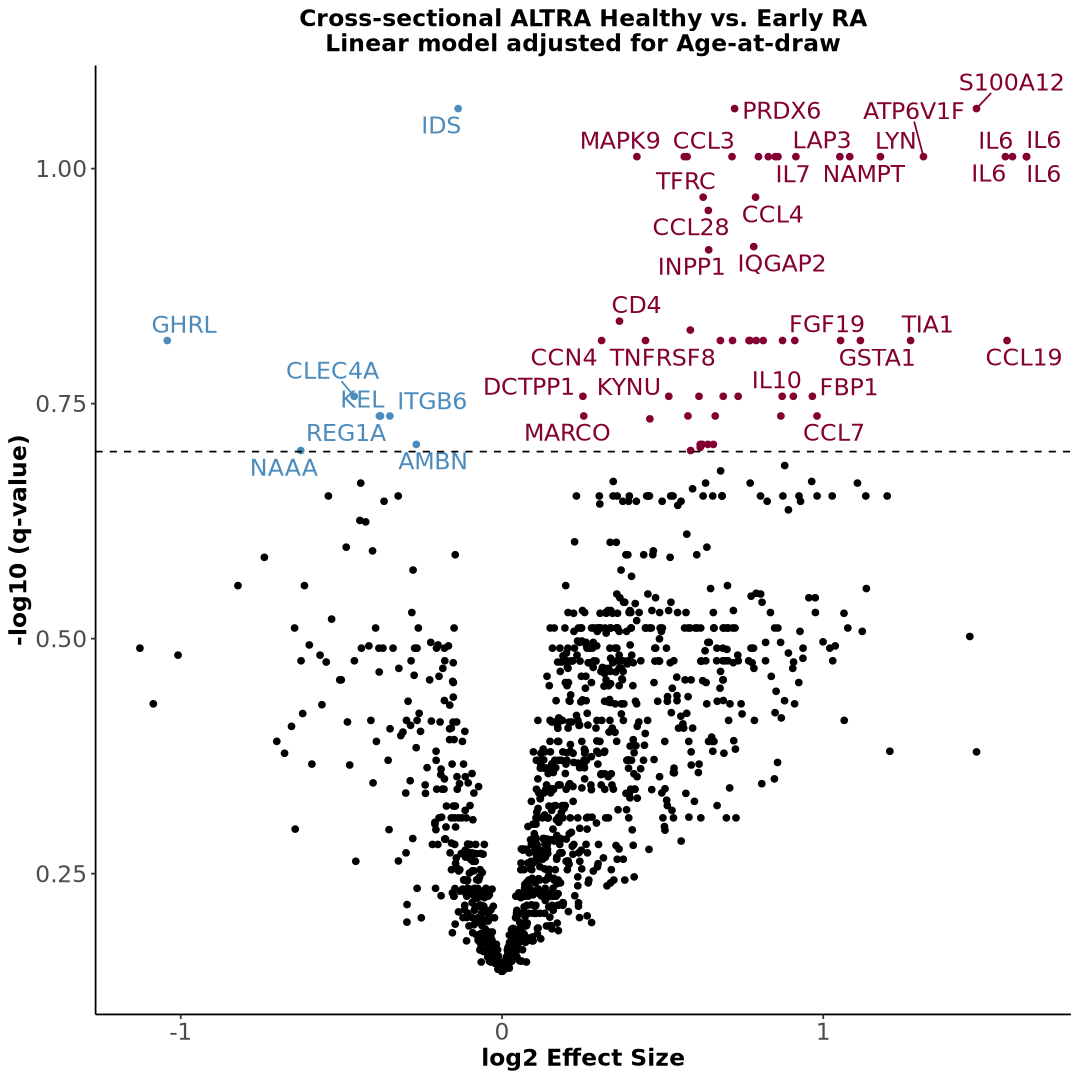

In [34]:
options(repr.plot.width = 9, repr.plot.height = 9)


ggplot(modelEraDF, aes(x=Estimate,
                       y=-log10(qval), 
                       colour=pcat, 
                       label=ifelse(pcat != 'NS', 
                                    Assay, 
                                    ''))) + 
    geom_point() + 
    geom_text_repel(size = 5) + 
    scale_colour_manual(values = c('#4C8CBD',
                                   'black', 
                                   '#840032')) +  
    geom_hline(yintercept = -log10(0.2), 
               linetype = 'dashed') + 
    labs(title='Cross-sectional ALTRA Healthy vs. Early RA\nLinear model adjusted for Age-at-draw',
         x='log2 Effect Size', 
         y='-log10 (q-value)') + 
    theme_classic() + 
    theme (plot.title = element_text(size=14, face='bold', hjust=0.5), 
           legend.position = 'none',
           #legend.text = element_text(size = 14),
           #legend.title = element_text(size=14),
           axis.text.y = element_text(size = 14),
           axis.text.x = element_text(size = 14), 
           axis.title.y = element_text(size = 14, face='bold'), 
           axis.title.x = element_text(size = 14, face = 'bold'))

## Store results in HISE

In order to store the results in HISE, we'll need to cache these files to register them, and then we can upload the CSV files for later steps.

In [35]:
study_space_uuid <- "223de760-9624-45bd-aefe-ca24c75b1800"
title <- paste("ALTRA Olink Results Aim 2: CON | ERA (No Converters)", Sys.Date())

In [36]:
search_id = ids::proquint(n_words = 3)
search_id

[1] "binaj-dasoh-finom"

In [37]:
in_list <- list(olink_uuid, meta_uuid)

In [38]:
outFiles

[[1]]
[1] "/home/workspace/temp/output/2025-02-07_ERA_lm_allVariables.csv"

[[2]]
[1] "/home/workspace/temp/output/2025-02-07_ERA_lm_EraVariable.csv"

[[3]]
[1] "/home/workspace/temp/output/2025-02-07_ERA_lm_visualization_format.csv"

In [39]:
uploadFiles(
    files = outFiles,
    studySpaceId = study_space_uuid,
    title = title,
    inputFileIds = in_list,
    destination = search_id,
    store = "project",
    doPrompt = FALSE
)

$Message
[1] "General Okay-ness"

$VisualizationId
[1] "00000000-0000-0000-0000-000000000000"

$AbstractionId
[1] "00000000-0000-0000-0000-000000000000"

$TraceId
[1] "ee17d058-36d4-432c-9d61-d2cdc64b3935"

$ProcessId
[1] "ffef3bd3-b7fb-4643-a217-2e0a4f0fca6d"

$WorkflowId
[1] "9c8683ff-c597-4b6c-b287-8e1088a8756f"

$FileIds
$FileIds[[1]]
[1] "e632b980-d680-46d6-a43d-88ea5c77794c"

$FileIds[[2]]
[1] "74750863-0db2-4279-868e-6c5d8bb35db3"

$FileIds[[3]]
[1] "a056f4b8-a897-471a-8594-9fe2ceef6ef4"

## Session Info

In [40]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggrepel_0.9.5 ggplot2_3.5.1 qvalue_2.34.0 tibble_3.2.1  tidyr_1.3.1  
 [6] dplyr_1.1.4   furrr_0.3.1   future_1.34.0 purrr_1.0.2   hise_2.16.0  

loaded via a namespace (and not attached):
 [1] utf8_1.2.4        generics_0.1.3    bitops_1.0-8      stringi_1.8.4    
 [5] listenv_0.9.1     digest_0.6.36     ma